# 01 · Prosody Exploration on RAVDESS

**Goal:** Verify that the prosodic features in `backend/pipeline/prosody.py` actually discriminate between emotions.

If our PRAAT-based feature extractor is well-implemented, we should see literature-confirmed patterns when we group RAVDESS clips by emotion label:

| Feature | Expected pattern |
|---|---|
| F0 mean | anger / happy / surprised / fearful **high**; sad / calm **low** |
| F0 range | aroused emotions wider; calm/sad narrower |
| Intensity | anger / happy **high**; sad **low** |
| Jitter / Shimmer | fearful **elevated** (voice instability) |
| Voiced ratio | sad **higher** (longer voiced vowels); surprised **lower** |

These predictions come from **Banse & Scherer 1996** and **Juslin & Laukka 2003**.

**Dataset:** RAVDESS (Livingstone & Russo 2018) — 120 clips (Actors 01, 02). 2 sentences × 2 repetitions × 8 emotions × ~2 intensities = 60 clips per actor.


## 0 · Setup

In [1]:
import sys
from pathlib import Path

# Make `backend.pipeline.*` importable.
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from backend.pipeline.prosody import extract_prosody
from backend.pipeline.datasets import load_ravdess_clips

sns.set_theme(style="whitegrid", context="notebook")
RAVDESS_ROOT = PROJECT_ROOT / "data" / "datasets" / "RAVDESS"
print(f"Project root: {PROJECT_ROOT}")
print(f"RAVDESS root: {RAVDESS_ROOT}")

Matplotlib is building the font cache; this may take a moment.


Project root: /Users/birdhouse/Documents/GitHub/SoundShape
RAVDESS root: /Users/birdhouse/Documents/GitHub/SoundShape/data/datasets/RAVDESS


## 1 · Discover RAVDESS clips

In [2]:
clips = load_ravdess_clips(RAVDESS_ROOT)
print(f"Found {len(clips)} clips.")

meta_df = pd.DataFrame([
    {
        "path": str(c.path.relative_to(PROJECT_ROOT)),
        "actor": c.actor,
        "sex": c.actor_sex,
        "emotion": c.emotion,
        "intensity": c.intensity,
        "statement": c.statement,
        "repetition": c.repetition,
    }
    for c in clips
])

print("\nCount by emotion:")
print(meta_df.groupby(["emotion", "sex"]).size().unstack(fill_value=0))

Found 120 clips.

Count by emotion:
sex        female  male
emotion                
angry           8     8
calm            8     8
disgust         8     8
fearful         8     8
happy           8     8
neutral         4     4
sad             8     8
surprised       8     8


## 2 · Extract prosody features for every clip

~120 clips × ~0.5s extraction each → roughly a minute. The actor voices in RAVDESS are male-baritone and female-mezzo so the default 75–600 Hz pitch range covers them.

In [3]:
rows = []
for i, clip in enumerate(clips, start=1):
    result = extract_prosody(str(clip.path))
    rows.append({
        "path": str(clip.path.relative_to(PROJECT_ROOT)),
        "actor": clip.actor,
        "sex": clip.actor_sex,
        "emotion": clip.emotion,
        "intensity": clip.intensity,
        **result.features.to_dict(),
    })
    if i % 30 == 0:
        print(f"  {i}/{len(clips)} processed")

df = pd.DataFrame(rows)
print(f"\nFeature matrix: {df.shape}")
df.head()

  30/120 processed


  60/120 processed


  90/120 processed


  120/120 processed

Feature matrix: (120, 20)


,path,actor,sex,emotion,intensity,duration,f0_mean,f0_std,f0_min,f0_max,f0_range,intensity_mean,intensity_std,intensity_min,intensity_max,jitter_local,shimmer_local,hnr_mean,voiced_ratio,speech_rate_approx
0,data/datasets/RAVDESS/Actor_01/03-01-01-01-01-...,01,male,neutral,normal,3.303292,111.849012,17.726207,80.765572,157.814391,77.048818,13.611333,28.647546,-33.431415,58.394280,0.041895,0.137825,7.490394,0.308869,30.575562
1,data/datasets/RAVDESS/Actor_01/03-01-01-01-01-...,01,male,neutral,normal,3.336667,117.245068,18.327280,84.473408,163.597137,79.123729,15.508133,27.264048,-36.881801,59.077494,0.031211,0.172094,9.241042,0.321212,31.768232
2,data/datasets/RAVDESS/Actor_01/03-01-01-01-02-...,01,male,neutral,normal,3.269917,112.329468,15.661057,86.827031,146.774651,59.947620,14.725608,29.134024,-50.578343,59.963312,0.031797,0.127478,8.468531,0.325077,32.110910
3,data/datasets/RAVDESS/Actor_01/03-01-01-01-02-...,01,male,neutral,normal,3.169833,111.169592,16.161782,84.942462,146.511514,61.569053,16.049096,27.288902,-34.298108,59.728546,0.037675,0.116052,8.494923,0.313099,30.916452
4,data/datasets/RAVDESS/Actor_01/03-01-02-01-01-...,01,male,calm,normal,3.536854,117.901185,19.596982,83.595426,157.434160,73.838734,12.647445,34.568460,-300.000000,55.266915,0.036081,0.132570,8.063019,0.331429,32.797507


## 3 · Per-emotion feature statistics

Means and standard deviations of each scalar feature, grouped by emotion. **This is the table that, if it looks right, validates our feature extractor.**

In [4]:
feature_cols = [
    "f0_mean", "f0_range", "f0_std",
    "intensity_mean", "intensity_std",
    "jitter_local", "shimmer_local", "hnr_mean",
    "voiced_ratio", "speech_rate_approx",
]

emotion_order = [
    "neutral", "calm", "happy", "sad",
    "angry", "fearful", "disgust", "surprised",
]

summary = (
    df.groupby("emotion")[feature_cols]
    .mean()
    .reindex(emotion_order)
    .round(2)
)
summary

,f0_mean,f0_range,f0_std,intensity_mean,intensity_std,jitter_local,shimmer_local,hnr_mean,voiced_ratio,speech_rate_approx
emotion,,,,,,,,,,
neutral,177.57,161.76,37.69,6.41,58.35,0.03,0.13,9.43,0.31,30.76
calm,164.20,157.18,31.57,1.19,67.16,0.02,0.10,11.73,0.38,37.22
happy,212.16,249.56,54.07,17.09,50.53,0.02,0.12,10.51,0.36,35.89
sad,180.99,148.48,29.40,-7.37,81.32,0.02,0.11,11.34,0.34,33.63
angry,256.81,258.26,58.63,18.35,65.80,0.02,0.12,9.05,0.34,33.51
fearful,280.41,160.39,31.69,25.46,49.01,0.02,0.10,12.64,0.35,34.80
disgust,203.90,275.13,55.08,3.44,74.34,0.03,0.12,8.95,0.32,32.17
surprised,234.71,280.22,71.54,5.97,69.68,0.03,0.14,7.55,0.31,30.96


## 4 · Visualize: boxplots of each feature by emotion

Reading these:
- **Wide box, high median** = the feature is *elevated* and *variable* for this emotion.
- **Big differences between emotion boxes** = the feature is **discriminative** (good for our pipeline).
- **Overlapping boxes** = the feature alone won't separate those emotions (we need multiple features together — which is exactly why we extract many).

Color-coded by Russell valence × arousal quadrant for cognitive grouping.

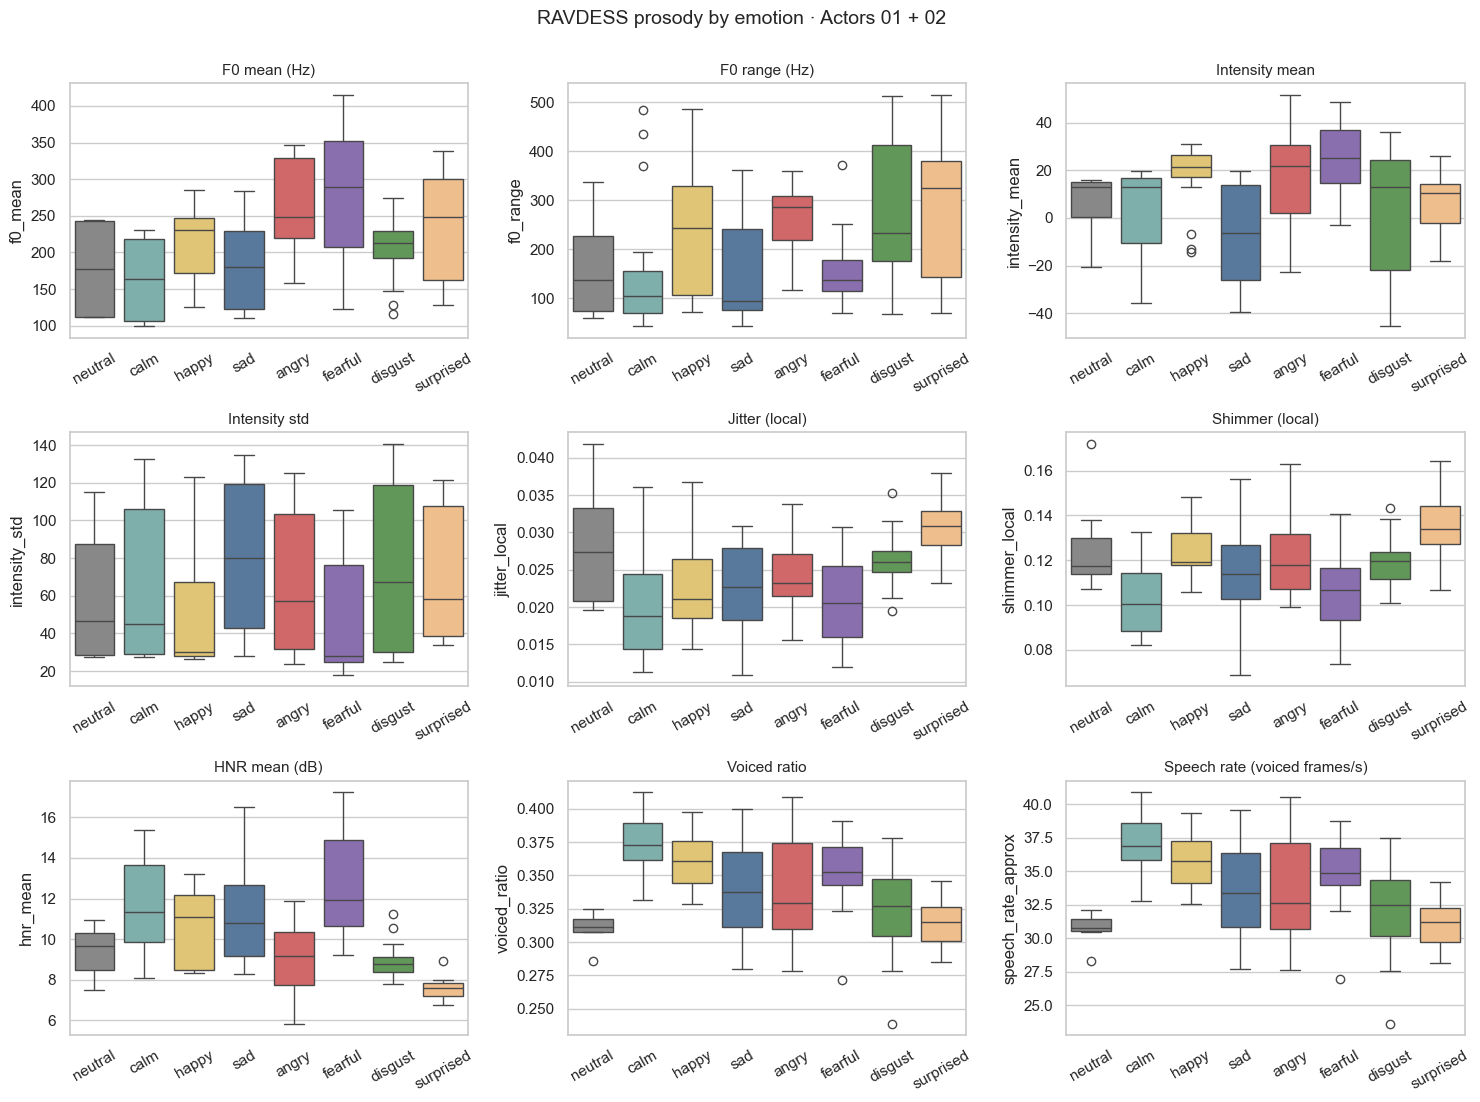

In [5]:
# Color each emotion by its rough valence × arousal quadrant.
emotion_color = {
    "neutral":   "#888888",
    "calm":      "#76b7b2",
    "happy":     "#f1ce63",
    "surprised": "#ffbe7d",
    "sad":       "#4e79a7",
    "angry":     "#e15759",
    "fearful":   "#8964b8",
    "disgust":   "#59a14f",
}

plot_features = [
    ("f0_mean", "F0 mean (Hz)"),
    ("f0_range", "F0 range (Hz)"),
    ("intensity_mean", "Intensity mean"),
    ("intensity_std", "Intensity std"),
    ("jitter_local", "Jitter (local)"),
    ("shimmer_local", "Shimmer (local)"),
    ("hnr_mean", "HNR mean (dB)"),
    ("voiced_ratio", "Voiced ratio"),
    ("speech_rate_approx", "Speech rate (voiced frames/s)"),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, (col, title) in zip(axes.flat, plot_features):
    sns.boxplot(
        data=df,
        x="emotion",
        y=col,
        order=emotion_order,
        hue="emotion",
        palette=emotion_color,
        legend=False,
        ax=ax,
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelrotation=30)

fig.suptitle("RAVDESS prosody by emotion · Actors 01 + 02", fontsize=14, y=1.00)
fig.tight_layout()
plt.show()

## 5 · Russell scatter — F0 mean × Intensity mean

If the literature's predictions hold, plotting F0 mean against intensity mean should *roughly* recreate the Russell valence × arousal plane:

```
                  intensity ↑ (arousal)
                        |
             angry      |    happy / surprised
  ────────────────────────────────── F0 →
             sad        |    calm / neutral
                        |
                  intensity ↓
```

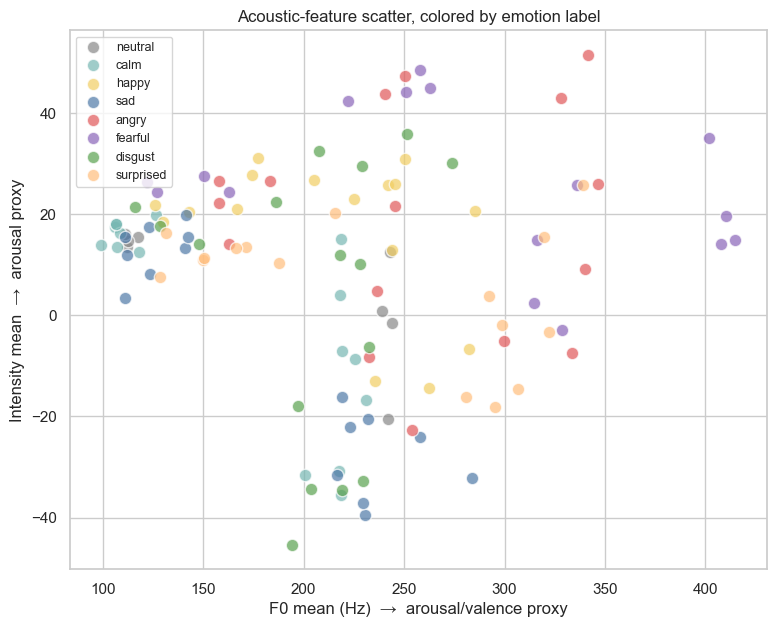

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))
for emo in emotion_order:
    sub = df[df["emotion"] == emo]
    ax.scatter(
        sub["f0_mean"],
        sub["intensity_mean"],
        c=emotion_color[emo],
        s=80,
        alpha=0.7,
        edgecolor="white",
        linewidth=1,
        label=emo,
    )
ax.set_xlabel("F0 mean (Hz)  →  arousal/valence proxy")
ax.set_ylabel("Intensity mean  →  arousal proxy")
ax.set_title("Acoustic-feature scatter, colored by emotion label")
ax.legend(loc="upper left", fontsize=9, frameon=True)
plt.show()

## 6 · Save the feature table

Persisted to `data/timelines/ravdess_prosody.csv` so downstream notebooks (Phase 3 emotion classifier, Phase 5 mapping calibration) can re-use it without re-running extraction.

In [7]:
out_path = PROJECT_ROOT / "data" / "timelines" / "ravdess_prosody.csv"
df.to_csv(out_path, index=False)
print(f"Wrote {out_path.relative_to(PROJECT_ROOT)} — {df.shape[0]} rows × {df.shape[1]} cols")

Wrote data/timelines/ravdess_prosody.csv — 120 rows × 20 cols


## 7 · What the plots should tell us

Read each subplot against the table at the top of this notebook. If most predictions hold, the feature extractor is sound and Phase 2's exit criterion is met:

> *Re-explainer test — can I look at the F0 boxplot and articulate why anger sits higher than sadness?*

Cases where the prediction doesn't hold are also interesting — those are the emotions where prosody alone is ambiguous and where wav2vec2's deep embeddings (Phase 3) will need to pick up the slack.